# Lecture 7: Confidence Intervals

In [24]:
import random

# import pylab
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate

## Getting normally distributed data

Fraction within ~200 of mean =  0.9505809999999943


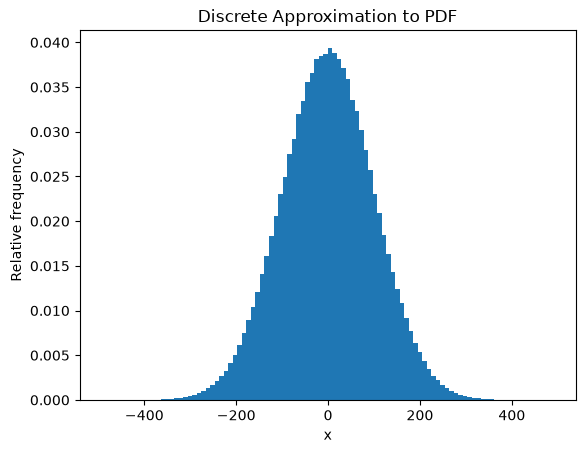

In [15]:
dist, numSamples = [], 1_000_000
for i in range(numSamples):
    dist.append(random.gauss(0, 100))  # we define the mean and the std

weights = [1 / numSamples] * len(dist)  # just a list with the weights for all numbers

v = plt.hist(
    dist,
    bins=100,
    weights=weights,  # amaizng parameter to have the fraction (%) "more interpretable"
)
plt.title("Discrete Approximation to PDF")
plt.ylabel("Relative frequency")
plt.xlabel("x")
print(
    "Fraction within ~200 of mean = ", sum(v[0][30:70])
)  # basically, what fraction of the values falls within 2 std of the mean!
# as a chekc of the empirical rule

plt.show()

## PDF for a normal distribution

- Remember: the **Probability Density Fucntion** describes the density of the probabilty distributed along the random variable. The CDF describes how the probability is acumulated, the PDF is describing how that probability accumulation is chaning per an infinitesimal change in the RV, it is going faster or slower? that is why it can be more than 1. It is like water, if we put water in a small container the density is huge, while if the conatiner is broad, the density will be small.

In [38]:
def gaussian(x, mu, sigma):
    factor1 = 1.0 / (sigma * ((2 * np.pi) ** 0.5))
    factor2 = np.e ** -(((x - mu) ** 2) / (2 * sigma**2))
    return factor1 * factor2

Text(0.5, 1.0, 'Normal Distribution, my = 0 \n, sigma = 1')

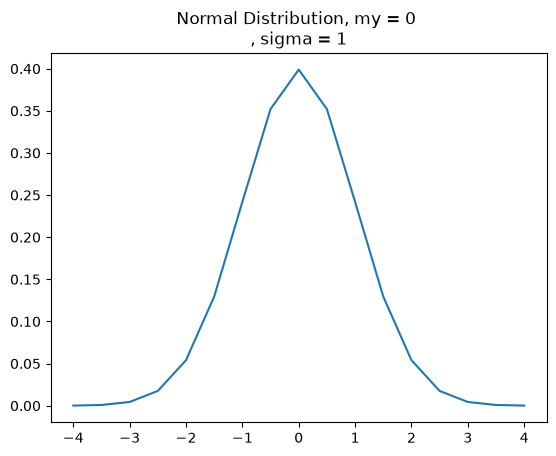

In [39]:
# given some numbers betwen -4 and 4 (not random) we calculate the corresponding gaussian density probability
xVals, yVals = [], []
mu, sigma = 0, 1

x = -4

while x <= 4:
    xVals.append(x)
    yVals.append(gaussian(x, mu, sigma))
    x += 0.5

plt.plot(xVals, yVals)
plt.title(f"Normal Distribution, my = {mu} \n, sigma = {sigma}")

- How can we interpret these values in the y-axis? we know that continous random varialbes can't have a probaility more than 0!
- They are densities!!! Again, it is the derivative of the cumulative distribution funciton.

In [40]:
def checkEmpirical(numTrials):
    for t in range(numTrials):
        mu = random.randint(-10, 10)
        sigma = random.randint(1, 10)
        print(f"For mu {mu} and sigma {sigma}")
        for numStd in (1, 1.96, 3):
            area = scipy.integrate.quad(
                gaussian,  # the function that we want to integrate (integrand)
                mu - numStd * sigma,  # lower bound
                mu + numStd * sigma,  # upper bound
                (mu, sigma),
            )[
                0
            ]  # this function provides the inggral value and the errors, we want rthe first one
            print(f" Fraction within {numStd} std = {round(area,4)}")

In [41]:
checkEmpirical(5)

For mu 4 and sigma 4
 Fraction within 1 std = 0.6827
 Fraction within 1.96 std = 0.95
 Fraction within 3 std = 0.9973
For mu 7 and sigma 3
 Fraction within 1 std = 0.6827
 Fraction within 1.96 std = 0.95
 Fraction within 3 std = 0.9973
For mu 8 and sigma 6
 Fraction within 1 std = 0.6827
 Fraction within 1.96 std = 0.95
 Fraction within 3 std = 0.9973
For mu -10 and sigma 8
 Fraction within 1 std = 0.6827
 Fraction within 1.96 std = 0.95
 Fraction within 3 std = 0.9973
For mu -6 and sigma 2
 Fraction within 1 std = 0.6827
 Fraction within 1.96 std = 0.95
 Fraction within 3 std = 0.9973


## Central Limit Theorem

- Given a sufficiently large sample, these three things will be true:

1. The mean of the samples in a set of samples (of the sample haha) will be appproximately normal distributed. Remember that a population is nothing more than a set of samples, and a sample is just a subsample of the population. So given a sample, and its subsets where we calculate the mean, the samples will approximate to an normal distribution as the sample gets larger and larger!
2. The sampel mean will approximate to the population mean
3. The variance of the sample will be approximate to the population variance divided by the sample size. It is pure logic, the mean of the sample will be more accurate as we increase the number of samples. If we try to estimate the height of Peruvians, using only 1 sample, the variance will be huge, but as we increase the number of samples, it will be decreasing.

Lets check it!

In [45]:
def GetMeanAndStd(X):
    mean = sum(X) / float(len(X))
    tot = 0.0
    for x in X:
        tot += (x - mean) ** 2
    std = (tot / len(X)) ** 0.5

    return mean, std

In [57]:
def plotMeans(numDice, numRolls, numBins, legend, color, style):
    """
    Function to simulate the roll of numDice Dices, calculating the mean
    in each trial, the trials are caculated by dividing the total number of rolls
    by the number of dice, example we have 10 rolls and 2 dices, we will simualte 5 rolls,
    inside reach roll we roll all dices and calculate the mean.
    """
    means = []
    for i in range(numRolls // numDice):  # rolls per dice
        vals = 0
        for j in range(numDice):
            vals += (
                5 * random.random()
            )  # here we want to add random numbers from 0 to 5 per the number of di

        means.append(vals / float(numDice))  # we just hwant the mean per dice

    plt.hist(
        means,
        bins=numBins,
        color=color,
        label=legend,
        weights=np.ones(len(means)) / len(means),
        hatch=style,
    )

    return GetMeanAndStd(means)

Mean of rolling 1 die = 2.499715986788619 std = 1.4431468537839265
Mean of rolling 50 die = 2.4997999226944585 std = 0.20358491165288561


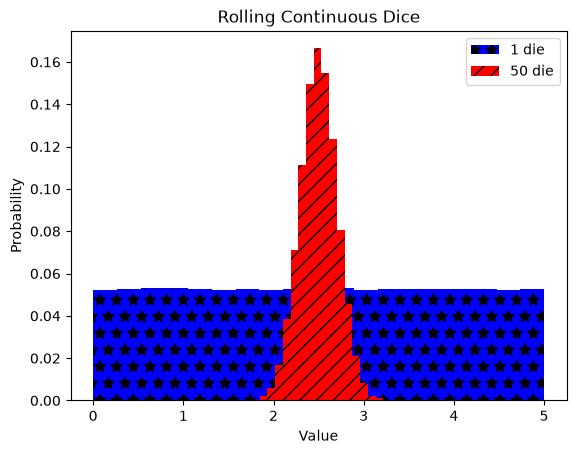

In [61]:
mean, std = plotMeans(1, 1000000, 19, "1 die", "b", "*")
print(f"Mean of rolling 1 die = {mean} std = {std}")
mean, std = plotMeans(50, 1000000, 19, "50 die", "r", "//")
print(f"Mean of rolling 50 die = {mean} std = {std}")
plt.title("Rolling Continuous Dice")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.legend()
plt.show()

- Something really interesting is that both experiments have the same amount of rolls! or trials, what we changed is the length of the sample
- The first experiment has a sample of 1, and we calculate the mean, while the second one works with a sample of 50!
- THis is the CLI!

In [63]:
class FairRoulette:
    def __init__(self):
        self.pockets = []
        for i in range(1, 37):
            self.pockets.append(i)
        self.ball = None
        self.pocketOdds = len(self.pockets) - 1

    def spin(self):
        self.ball = random.choice(self.pockets)

    def betPocket(self, pocket, amt):
        if str(pocket) == str(self.ball):
            return amt * self.pocketOdds
        else:
            return -amt

    def __str__(self):
        return "Fair Roulette"


def playRoulette(game, numSpins, pocket, bet, toPrint):
    totPocket = 0
    for i in range(numSpins):
        game.spin()
        totPocket += game.betPocket(pocket, bet)
    if toPrint:
        print(numSpins, "spins of", game)
        print(
            "Expected return betting",
            pocket,
            "=",
            str(100 * totPocket / numSpins) + "%\n",
        )
    return totPocket / numSpins


def findPocketReturn(game, numTrials, trialSize, toPrint):
    pocketReturns = []
    for t in range(numTrials):
        trialVals = playRoulette(game, trialSize, 2, 1, toPrint)
        pocketReturns.append(trialVals)
    return pocketReturns

Text(0.5, 1.0, 'Expected return betting a poclet of 200 times')

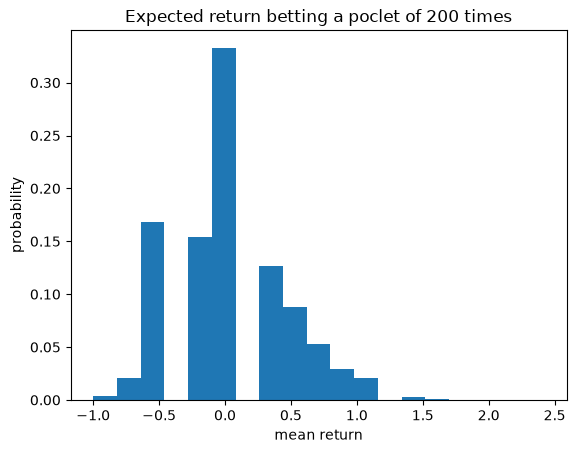

In [65]:
numTrials = 1_000_000
numSpins = 200
game = FairRoulette()

means = []
for i in range(numTrials):
    means.append(findPocketReturn(game, 1, numSpins, False)[0])

plt.hist(
    means,
    bins=19,
    weights=np.ones(len(means)) / len(means),
)

plt.xlabel("mean return")
plt.ylabel("probability")
plt.title("Expected return betting a poclet of 200 times")

- It does not matter the shape of the original distribution, if we try to estimate the mean and the sample is sufficiently large, the CLT will allow us to use the empircal rule when computing confidence intervals

### π Estimation: Laplace & Buffon

- THe experiment is interesting, given a circle inside a 2x2 square and radio 1, the area is equal to pi. Now, what would happen if we drop needles inside this are? some of the needles will fall inside the circle and other outside the circle randomly, we can say that if we have infinite needles, the rati of needles that fell inside the circle over the ones that fall inside the square is equa to the area of the circle over the area of the square! Solving fro the area of the circle we have a beautiful way to find the value of pi with a monte carlo simulation

- It is a great example of how we can estimate or solve problems that are not random with stochastic thinking! 

In [85]:
def throwNeeddles(numNeedles):
    inCircle = 0
    for Needles in range(1, numNeedles + 1, 1):
        x = random.random()
        y = random.random()

        if (x * x + y * y) ** 0.5 <= 1:
            inCircle += 1

    return 4 * (
        inCircle / float(numNeedles)
    )  # the formula for pi given the needles experiment, 4 is the area of the square

In [87]:
def getEst(numNeedles, numTrials):
    estimates = []
    for t in range(numTrials):
        piGuess = throwNeeddles(numNeedles)
        estimates.append(piGuess)
    # we calculate a set of estimates for pi using our method
    sDev = np.std(estimates)

    curEst = sum(estimates) / len(estimates)  # avg for the estimates

    print(
        f"Est. = {round(curEst, 6)} \n sDev. = {round(sDev, 6)}\n Needles = {numNeedles}"
    )

    return (curEst, sDev)

In [89]:
def estPi(precision, numTrials):
    numNeedles = 1000
    sDev = precision
    while (
        sDev >= precision / 2
    ):  # while the precision is no more than a half of what we want..
        curEst, sDev = getEst(numNeedles, numTrials)
        numNeedles *= 2

    return curEst


estPi(0.005, 100)

Est. = 3.14844 
 sDev. = 0.047662
 Needles = 1000
Est. = 3.1407 
 sDev. = 0.03457
 Needles = 2000
Est. = 3.14124 
 sDev. = 0.02812
 Needles = 4000
Est. = 3.142675 
 sDev. = 0.017712
 Needles = 8000
Est. = 3.14107 
 sDev. = 0.013405
 Needles = 16000
Est. = 3.139918 
 sDev. = 0.007789
 Needles = 32000
Est. = 3.142356 
 sDev. = 0.006318
 Needles = 64000
Est. = 3.141429 
 sDev. = 0.005203
 Needles = 128000
Est. = 3.141003 
 sDev. = 0.002834
 Needles = 256000
Est. = 3.141595 
 sDev. = 0.002114
 Needles = 512000


3.1415953125

- Interesting, when we double the number of needles, at some point the estimate gets worse!
- Even though the standard deviation is better, that does no tmean that we have the right answer.
- Statistics can tell us something about how reproducible our simulation is, but now if the simulation is but whether if the simulation is accurate! 
- So we always need sanity checks

### Conclusions:

Is it correct to state

1. 95% of the time we run this simulation, we will estimate that the value of pi is between 3.137438758 and 3.145674678
2. With a probability of 0.95 of the actual value of pi is between those numbers?

- Both are actually correct
- But only one of these statemtens can be infereded from the simulatin 

**Again , statiscally valid != true**
